# Cyclistic Case Study – Analyze

This notebook explores differences in **bike usage patterns between annual members and casual riders** using the cleaned dataset.

## Analysis Objective

The objective of this analysis is to identify behavioral differences between annual members and casual riders.  
These insights will help Cyclistic design targeted marketing strategies aimed at converting casual riders into annual members.

## Scope of Analysis

The analysis focuses on:
- Trip duration
- Ride frequency
- Time of day usage
- Weekday vs weekend behavior
- Seasonal patterns

All analyses that measure ride volume and temporal patterns
(e.g. ride counts, weekday vs weekend usage, time‑of‑day trends)
are performed on the full dataset.

Behavioral characteristics that require distribution‑based metrics
(e.g. trip duration) are analyzed using a balanced and reproducible
sample of trips to ensure computational efficiency and fair
comparison between rider types.


All analysis is performed using SQL queries on the processed dataset.


## DataBase connection


In [72]:
from sqlalchemy import create_engine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

server = "Knok\\SQLEXPRESS"
database = "Analysis"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

# Population‑Level Analysis (Full Dataset)

This section analyzes ride volume and temporal usage patterns
using the complete dataset. These analyses answer questions
related to frequency, timing, and seasonality.


In [73]:
query_population = """
SELECT
    member_casual,
    is_weekend,
    start_hour,
    DATEADD(MONTH, DATEDIFF(MONTH, 0, started_at), 0) AS year_month,
    COUNT(*) AS total_rides
FROM dbo.cyclistic
GROUP BY
    member_casual,
    is_weekend,
    start_hour,
    DATEADD(MONTH, DATEDIFF(MONTH, 0, started_at), 0);
"""

df_pop = pd.read_sql(query_population, con=engine)
df_pop.shape


(6912, 5)

## Analysis 01: Weekday vs Weekend Usage by Rider Type

How does ride frequency differ between annual members and casual riders during weekdays and weekends?

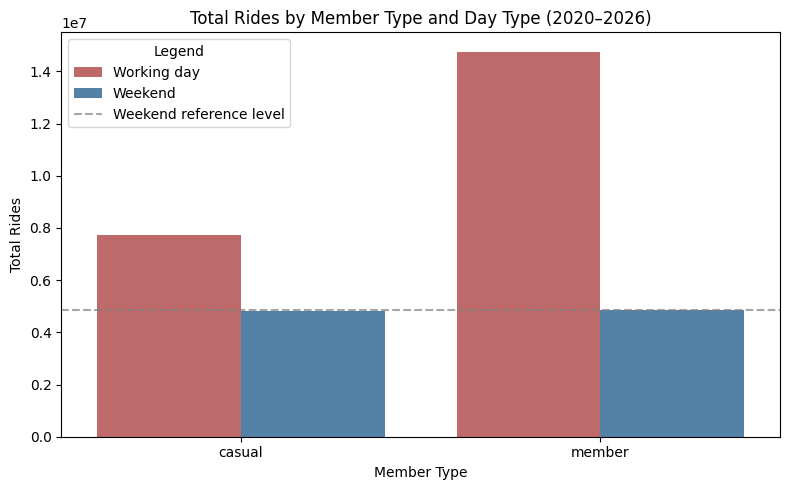

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Population-level analysis: Weekday vs Weekend ride volume
# ---------------------------------------------------------

# Aggregate total rides by rider type and day type
df_weekend = (
    df_pop
    .groupby(["member_casual", "is_weekend"])["total_rides"]
    .sum()
    .reset_index()
)

# Map boolean weekend indicator to readable labels
df_weekend["day_type"] = df_weekend["is_weekend"].map({
    True: "Weekend",
    False: "Working day"
})

# Reference level: average weekend rides across both rider types
weekend_ref = (
    df_weekend[df_weekend["day_type"] == "Weekend"]["total_rides"]
    .mean()
)

# Color palette for readability
palette = {
    "Working day": "indianred",
    "Weekend": "steelblue"
}

# Plot
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_weekend,
    x="member_casual",
    y="total_rides",
    hue="day_type",
    palette=palette,
    errorbar=None
)

# Add reference line for weekend comparison
ax.axhline(
    weekend_ref,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="Weekend reference level"
)

# Titles and labels
ax.set_title("Total Rides by Member Type and Day Type (2020–2026)")
ax.set_xlabel("Member Type")
ax.set_ylabel("Total Rides")

# Clean legend (avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Legend")

plt.tight_layout()
plt.show()

### Insight

Annual members account for substantially more rides during weekdays
compared to casual riders, indicating routine and commute‑oriented usage.
On weekends, ride volumes between the two groups are more comparable,
suggesting leisure‑oriented behavior across both rider types.


### Business Relevance


The largest behavioral difference between rider types occurs during weekdays.
This suggests that marketing strategies should emphasize the value of annual
membership for frequent weekday transportation rather than weekend leisure use.


## Analysis 02: Time Series – Usage Over Time (Context)




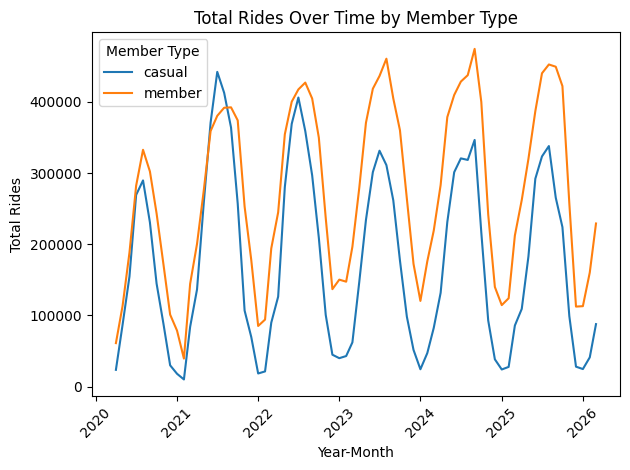

In [75]:
df_time_series = (
    df_pop
    .groupby(["year_month", "member_casual"])["total_rides"]
    .sum()
    .reset_index()
)

palette = {
    "casual": "#1f77b4",   # modrá
    "member": "#ff7f0e"    # oranžová
}


sns.lineplot(data=df_time_series, x="year_month", y="total_rides", palette=palette, hue="member_casual")
plt.title("Total Rides Over Time by Member Type")
plt.xlabel("Year-Month")
plt.ylabel("Total Rides")
plt.legend(title="Member Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly ride volumes reveal strong seasonality across both rider groups, with usage
peaking during summer months. While both casual and annual riders follow similar
seasonal patterns, annual members consistently generate a higher number of rides
throughout the year. This suggests more frequent and routine usage among members,
independent of seasonal effects.

This time series provides contextual insight into overall demand and
seasonality. While annual members consistently generate more rides,
this analysis reflects ride volume rather than membership growth.

Due to the absence of user‑level identifiers, increases in member ride
counts cannot be directly attributed to growth in the number of members.

we are still not sure if member increase is caused by bigger usage per customer or overall membership inncrease
- analysis needed :  duration, membership increase, the most frequent times


The analysis compares trip‑level behavior between annual members and casual riders.
Since the dataset does not contain unique user identifiers, trips were used as the
unit of analysis. Group‑level behavioral differences were inferred based on the
attributes of each trip.


## Analysis 03: Ride frequency: members vs casual (overall)


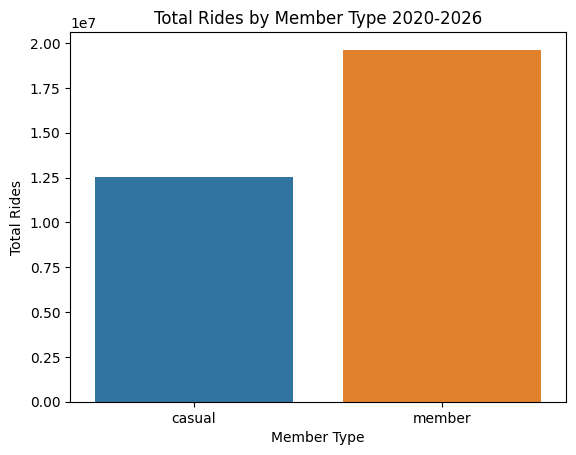

In [76]:


sns.barplot(
    data=df_pop.groupby("member_casual")["total_rides"].sum().reset_index(),
    x="member_casual",
    y="total_rides",
    palette=palette,
    hue="member_casual",
)
plt.title("Total Rides by Member Type 2020-2026")
plt.xlabel("Member Type")
plt.ylabel("Total Rides")
plt.show()

Annual members generated a higher total number of rides than casual riders
over the observed period (2020–2026). This result reflects overall usage volume
rather than the number of unique riders.


Higher ride volume among annual members suggests more frequent usage over time.
This provides initial context for subsequent analyses examining when and how
members use Cyclistic bikes compared to casual riders.


Population‑level analyses were used to understand when and how often Cyclistic bikes are used by different rider types. These analyses provide contextual insight into usage volume and temporal patterns but do not describe individual‑level behavior.

## Analysis 04: most frequent times of the day


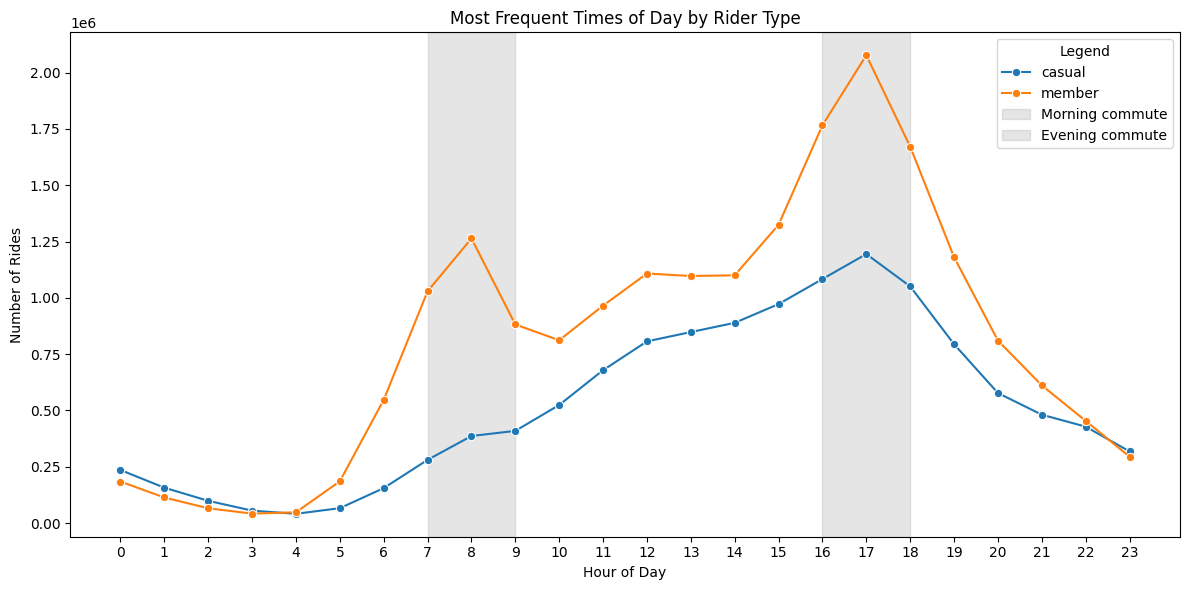

In [77]:
df_hourly = (
    df_pop
    .groupby(["member_casual", "start_hour"])["total_rides"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=df_hourly,
    x="start_hour",
    y="total_rides",
    hue="member_casual",
    palette=palette,
    marker="o"
)

# Interval Highlighting
ax.axvspan(7, 9, color="grey", alpha=0.2, label="Morning commute")
ax.axvspan(16, 18, color="grey", alpha=0.2, label="Evening commute")

plt.title("Most Frequent Times of Day by Rider Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))

# Interval Legend addition
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Legend")

plt.tight_layout()
plt.show()




### Insight


Annual members exhibit clear peaks in bike usage during typical commuting hours.
The highest ride volumes occur in the morning (7–9) and late afternoon (16–18),
which is consistent with routine travel to and from work.

Casual riders show a more evenly distributed usage pattern throughout the day,
with peak activity occurring later in the afternoon. This difference further
supports the interpretation that annual members primarily use Cyclistic bikes
for commuting, while casual riders use them more for leisure.

### Business Relevance

# Behavioral Analysis (Sample‑Based)

This section focuses on trip‑level behavior using a stratified
random sample of rides. Sampling allows for distribution‑based
analysis while ensuring balanced comparison between rider types.


While population‑level analyses show when and how often bikes are used,
trip duration provides deeper insight into the nature of that usage.
The following analysis examines behavioral differences using a balanced
sample of trips.

## Sample Construction

To enable fair behavioral comparison between annual members and casual riders,
a stratified random sample of trips was created. Trips were sampled evenly
across years and rider types to avoid volume‑driven bias while preserving
temporal representation.

Sampling was performed at the trip level, as the dataset does not contain
unique user identifiers.

In [78]:
query_sample = """
WITH base AS (
    SELECT
        ride_id,
        member_casual,
        started_at,
        duration,
        is_weekend,
        start_hour,
        YEAR(started_at) AS year
    FROM dbo.cyclistic
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, member_casual
            ORDER BY ABS(CHECKSUM(ride_id))
        ) AS rn
    FROM base
)
SELECT
    ride_id,
    member_casual,
    started_at,
    duration,
    is_weekend,
    start_hour,
    year
FROM ranked
WHERE rn <= 300
ORDER BY year, member_casual;
"""

df_sample = pd.read_sql(query_sample, con=engine)
df_sample.shape

(4200, 7)

In [79]:
df_sample.head()

,ride_id,member_casual,started_at,duration,is_weekend,start_hour,year
0,67925855CE4B9BD5,casual,2020-08-26 18:03:57,63,False,18,2020
1,AF70AA60FE595B57,casual,2020-10-10 11:37:53,100,True,11,2020
2,4FC87E46715B5EDB,casual,2020-09-05 18:04:56,22,True,18,2020
3,108CFB0329694CA2,casual,2020-07-06 22:18:48,36,False,22,2020
4,AA1F60D01C00800A,casual,2020-09-14 20:32:06,12,False,20,2020


In [80]:

df_pop.to_pickle("data/df_pop.pkl")
df_sample.to_pickle("data/df_sample.pkl")


In [95]:
import pandas as pd

df_sample = pd.read_pickle("data/df_sample.pkl")

df_sample.describe()

,started_at,duration,start_hour,year
count,4200,4200.000000,4200.000000,4200.000000
mean,2023-07-05 06:31:16.264047,21.313810,14.195238,2023.000000
min,2020-04-01 16:40:05,0.000000,0.000000,2020.000000
25%,2021-09-18 06:03:37.500000,5.000000,11.000000,2021.000000
50%,2023-07-22 13:47:33.500000,10.000000,15.000000,2023.000000
75%,2025-06-07 14:57:10.500000,20.000000,18.000000,2025.000000
max,2026-03-31 23:10:36,1600.000000,23.000000,2026.000000
std,NaN,82.012819,4.921288,2.000238



## Analysis 05: duration per week and weekends


In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sample["day_type"] = df_sample["is_weekend"].map({
    True: "Weekend",
    False: "Working day"
})
df_duration = df_sample.groupby(["member_casual","day_type"])["duration"].mean().reset_index().round(2)


df_duration



,member_casual,day_type,duration
0,casual,Weekend,37.52
1,casual,Working day,26.08
2,member,Weekend,12.69
3,member,Working day,12.12


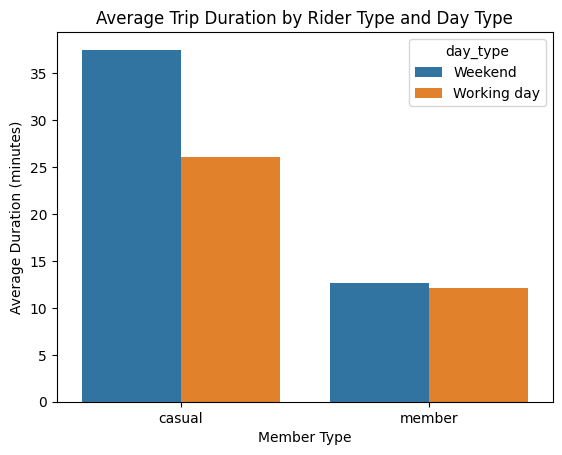

In [83]:


sns.barplot(
    data=df_duration,
    x="member_casual",
    y="duration",
    hue="day_type",
    errorbar=None
)
plt.title("Average Trip Duration by Rider Type and Day Type")
plt.xlabel("Member Type")
plt.ylabel("Average Duration (minutes)")
plt.show()

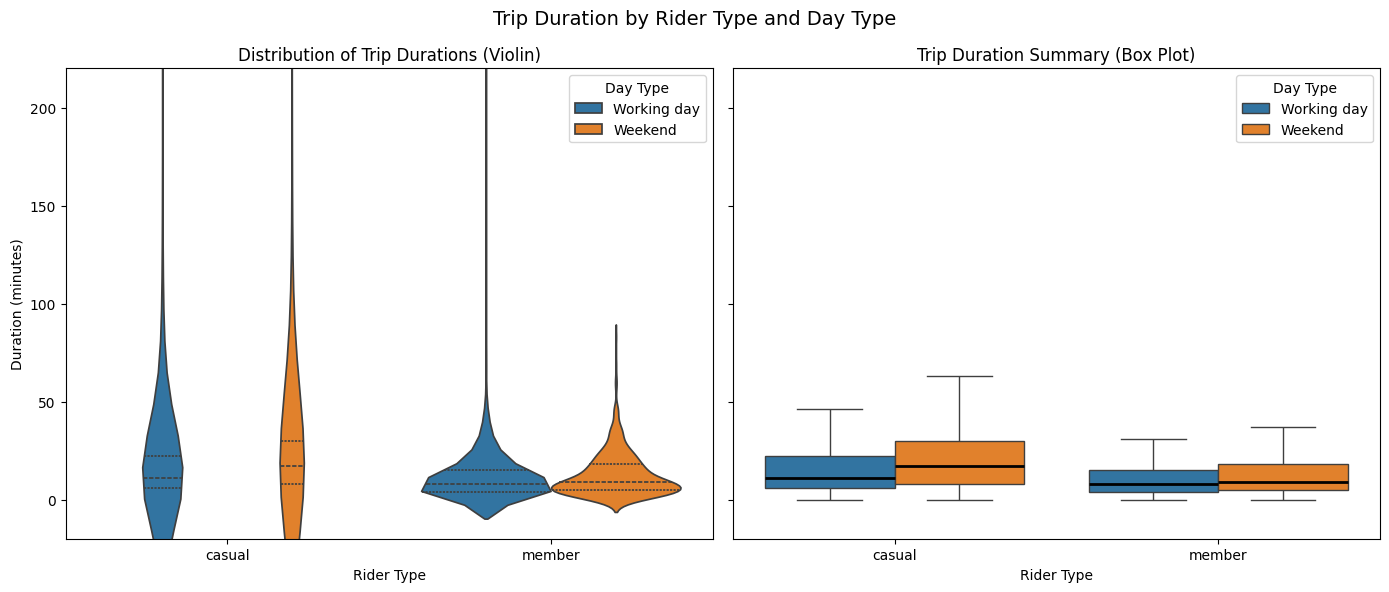

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------- Violin plot ----------
sns.violinplot(
    data=df_sample,
    x="member_casual",
    y="duration",
    hue="day_type",
    inner="quartile",
    split=False,
    ax=axes[0]
)

axes[0].set_title("Distribution of Trip Durations (Violin)")
axes[0].set_xlabel("Rider Type")
axes[0].set_ylabel("Duration (minutes)")
axes[0].legend(title="Day Type")

# ---------- Box plot ----------
sns.boxplot(
    data=df_sample,
    x="member_casual",
    y="duration",
    hue="day_type",
    showfliers=False,
    ax=axes[1],
    medianprops={"color": "black", "linewidth": 2}
)

axes[1].set_title("Trip Duration Summary (Box Plot)")
axes[1].set_xlabel("Rider Type")
axes[1].set_ylabel("")
axes[1].legend(title="Day Type")
axes[0].set_ylim(-20, 220)
axes[1].set_ylim(-20, 220)

plt.suptitle("Trip Duration by Rider Type and Day Type", fontsize=14)
plt.tight_layout()
plt.show()


## Analysis 06: Behaviour difference through the years


Sample‑based analysis of trip duration reveals clear behavioral differences
between rider types. Casual riders take significantly longer trips during
weekends compared to working days, indicating leisure‑oriented usage.

In contrast, annual members exhibit nearly identical average trip durations
on working days and weekends. This stability suggests that members primarily
use Cyclistic bikes for routine transportation purposes rather than leisure
activities.

In [85]:
df_year = (
    df_sample
    .groupby(["year", "member_casual"])["duration"]
    .median()
    .reset_index()
)
df_year.head()

,year,member_casual,duration
0,2020,casual,23.0
1,2020,member,12.5
2,2021,casual,17.0
3,2021,member,10.0
4,2022,casual,13.0


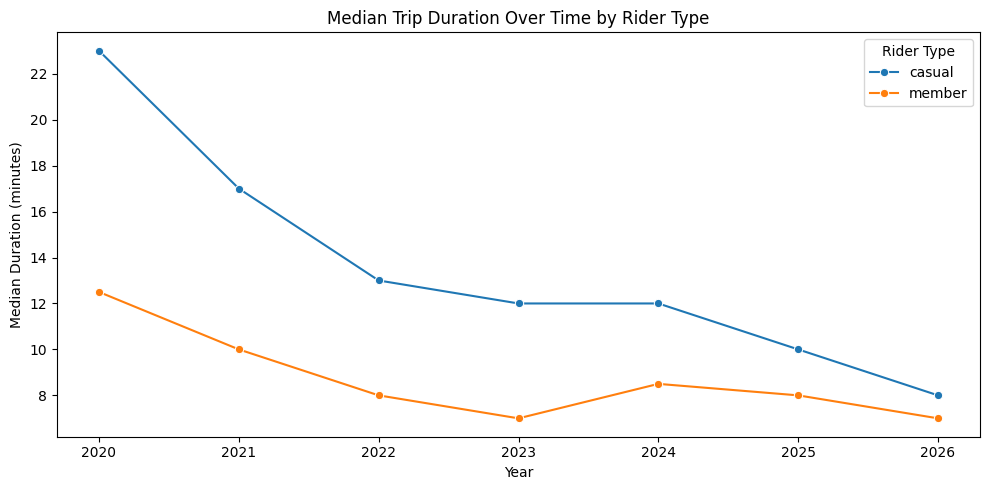

In [86]:


plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_year,
    x="year",
    y="duration",
    hue="member_casual",
    marker="o"
)

plt.title("Median Trip Duration Over Time by Rider Type")
plt.xlabel("Year")
plt.ylabel("Median Duration (minutes)")
plt.legend(title="Rider Type")
plt.tight_layout()
plt.show()


Median trip duration decreases over time for both annual members and casual riders.
This trend likely reflects increased system maturity, infrastructure expansion,
and greater availability of bikes, enabling shorter and more efficient trips.

Importantly, the relative difference between rider types remains consistent throughout
the observed period. Casual riders consistently take longer trips than annual members,
indicating stable and persistent differences in usage behavior over time
